# Install required packages

In [56]:
!pip install timm librosa --quiet
!pip install timm --quiet
!pip install grad-cam --quiet
!pip install captum --quiet
!pip install facenet-pytorch --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.7 MB/s eta 0:00:0000:0100:01


In [57]:
!pip uninstall -y Pillow
!pip install Pillow==10.2.0 --no-cache-dir --force-reinstall


Found existing installation: pillow 10.2.0
Uninstalling pillow-10.2.0:
  Successfully uninstalled pillow-10.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 55.6 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.5 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.2.2 which is incompatible.


In [58]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

# Patient ID to Diagnosis map

In [59]:
patient_diag_map = {
    101: 'URTI', 102: 'Healthy', 103: 'COPD', 104: 'COPD', 105: 'COPD',
    106: 'COPD', 107: 'URTI', 108: 'Healthy', 109: 'COPD', 110: 'Healthy',
    111: 'Healthy', 112: 'Healthy', 113: 'COPD', 114: 'Healthy', 115: 'Healthy',
    116: 'URTI', 117: 'Healthy', 118: 'Healthy', 119: 'Healthy', 120: 'COPD',
    121: 'Healthy', 122: 'COPD', 123: 'COPD', 124: 'Healthy', 125: 'Healthy',
    126: 'Healthy', 127: 'Healthy', 128: 'Healthy', 130: 'COPD', 131: 'Healthy',
    132: 'Healthy', 133: 'Healthy', 134: 'Healthy', 135: 'Healthy', 136: 'Pneumonia',
    137: 'Bronchiolitis', 138: 'URTI', 139: 'Healthy', 140: 'Healthy', 141: 'COPD',
    142: 'COPD', 143: 'COPD', 144: 'Healthy', 145: 'Healthy', 146: 'COPD',
    147: 'Healthy', 148: 'Bronchiectasis', 149: 'Healthy', 150: 'Pneumonia',
    151: 'Bronchiectasis', 152: 'Healthy', 153: 'Healthy', 154: 'Healthy',
    155: 'Healthy', 156: 'Healthy', 157: 'Bronchiectasis', 158: 'Pneumonia',
    159: 'Healthy', 160: 'Healthy', 161: 'Healthy', 162: 'COPD', 163: 'Bronchiolitis',
    164: 'Bronchiectasis', 165: 'Healthy', 166: 'COPD', 167: 'COPD', 168: 'COPD',
    169: 'COPD', 170: 'Healthy', 171: 'COPD', 172: 'COPD', 173: 'Healthy',
    174: 'COPD', 175: 'Healthy', 176: 'COPD', 177: 'LRTI', 178: 'Pneumonia',
    179: 'COPD', 180: 'Asthma', 181: 'COPD', 182: 'COPD'
}

# Mapping to 4 Classes
label_map_4class = {
    'COPD': 'COPD',
    'Healthy': 'Healthy',
    'Pneumonia': 'Infection',
    'URTI': 'Infection',
    'LRTI': 'Infection',
    'Bronchiolitis': 'OtherRD',
    'Bronchiectasis': 'OtherRD',
    'Asthma': 'OtherRD'
}

final_label_map = {'COPD': 0, 'Healthy': 1, 'Infection': 2, 'OtherRD': 3}

def get_patient_id(filename):
    return int(filename.split('_')[0])

# Spectrogram Generation

In [60]:
# Spectrogram Generation
AUDIO_DIR = '/kaggle/input/full-respiratory/ICBHI_final_database'  # Adjust if needed
OUTPUT_DIR = 'spectrograms_by_recording'
os.makedirs(OUTPUT_DIR, exist_ok=True)

spectrogram_data = []
generated = 0
errors = 0

for file in tqdm(os.listdir(AUDIO_DIR)):
    if file.endswith(".wav"):
        try:
            base = file[:-4]
            pid = int(file.split('_')[0])
            diagnosis = patient_diag_map.get(pid)
            if not diagnosis or diagnosis not in label_map_4class:
                continue
            label = final_label_map[label_map_4class[diagnosis]]

            wav_path = os.path.join(AUDIO_DIR, file)
            txt_path = wav_path.replace('.wav', '.txt')
            if not os.path.exists(txt_path):
                continue

            y, sr = librosa.load(wav_path, sr=None)
            with open(txt_path, 'r') as f:
                for i, line in enumerate(f):
                    parts = line.strip().split('\t')
                    if len(parts) < 2:
                        continue
                    start, end = float(parts[0]), float(parts[1])
                    seg = y[int(start * sr):int(end * sr)]
                    if len(seg) < 1000:
                        continue

                    mel = librosa.feature.melspectrogram(y=seg, sr=sr)
                    mel_db = librosa.power_to_db(mel, ref=np.max)

                    out_name = f"{base}_seg{i}_{label}.png"
                    out_path = os.path.join(OUTPUT_DIR, out_name)

                    plt.figure(figsize=(2, 2))
                    librosa.display.specshow(mel_db, sr=sr)
                    plt.axis('off')
                    plt.tight_layout()
                    plt.savefig(out_path, bbox_inches='tight', pad_inches=0)
                    plt.close()

                    spectrogram_data.append((out_path, label))
                    generated += 1
        except Exception as e:
            print(f"🚫 Error on {file}: {e}")
            errors += 1

print(f"\n✅ Total spectrograms generated: {generated}")
print(f"❌ Total errors: {errors}")

 30%|██▉       | 550/1843 [01:46<03:12,  6.73it/s]/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1848
  warnings.warn(
100%|██████████| 1843/1843 [05:36<00:00,  5.47it/s]


✅ Total spectrograms generated: 4787
❌ Total errors: 0


# Stratified Sampling (300 per class)

In [61]:
# Stratified Sampling (300 per class)
balanced = defaultdict(list)
for path, label in spectrogram_data:
    balanced[label].append((path, label))

subset = []
for label, items in balanced.items():
    subset.extend(items[:300])

paths, labels = zip(*subset)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = list(skf.split(paths, labels))[0]

train_data = [subset[i] for i in train_idx]
val_data = [subset[i] for i in val_idx]

# Custom Dataset
class SpectrogramDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        path, label = self.data[idx]
        img = plt.imread(path)
        img = (img * 255).astype(np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, label

# Transforms
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_loader = DataLoader(SpectrogramDataset(train_data, transform), batch_size=16, shuffle=True)
val_loader = DataLoader(SpectrogramDataset(val_data, transform), batch_size=16)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Resnet50

In [62]:
# Define ResNet50 model
resnet = models.resnet50(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, 4)  # 4-class classification
resnet.to(device)

# Loss Function with Class Weights
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# Optimizer
optimizer_resnet = torch.optim.Adam(resnet.parameters(), lr=1e-4)

# Training function
def train_model(model, loader, optimizer):
    model.train()
    loss_sum, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        correct += (out.argmax(1) == y).sum().item()
    return loss_sum / len(loader), correct / len(loader.dataset)

# Train for 10 epochs
for epoch in range(10):
    loss, acc = train_model(resnet, train_loader, optimizer_resnet)
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc*100:.2f}%")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Loss=1.0702, Accuracy=53.12%
Epoch 2: Loss=0.5018, Accuracy=81.67%
Epoch 3: Loss=0.3208, Accuracy=89.38%
Epoch 4: Loss=0.2381, Accuracy=92.19%
Epoch 5: Loss=0.1725, Accuracy=95.42%
Epoch 6: Loss=0.1095, Accuracy=96.46%
Epoch 7: Loss=0.0500, Accuracy=99.06%
Epoch 8: Loss=0.0854, Accuracy=97.29%
Epoch 9: Loss=0.0406, Accuracy=99.06%
Epoch 10: Loss=0.0449, Accuracy=98.65%


In [63]:
# ✅ Evaluate ResNet directly on validation set

def evaluate_resnet(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    print("✅ ResNet50 Evaluation Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1 Score:", f1_score(y_true, y_pred, average='macro'))
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["COPD", "HC", "Infected", "OtherRD"]))

# Run Evaluation
evaluate_resnet(resnet, val_loader)

✅ ResNet50 Evaluation Results:
Accuracy: 0.9083333333333333
Macro F1 Score: 0.9086222928072991
Classification Report:
               precision    recall  f1-score   support

        COPD       0.94      0.83      0.88        60
          HC       0.84      0.88      0.86        60
    Infected       0.87      0.97      0.91        60
     OtherRD       1.00      0.95      0.97        60

    accuracy                           0.91       240
   macro avg       0.91      0.91      0.91       240
weighted avg       0.91      0.91      0.91       240



# VGG19

In [64]:
# VGG19
vgg19 = timm.create_model('vgg19', pretrained=True, num_classes=4) # Assuming 4 classes
vgg19.to(device)
optimizer_vgg19 = torch.optim.Adam(vgg19.parameters(), lr=1e-4) 

In [65]:
# VGG19 Training
for epoch in range(10):
    loss, acc = train_model(vgg19, train_loader, optimizer_vgg19)
    print(f"VGG19 Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc*100:.2f}%")

VGG19 Epoch 1: Loss=1.3315, Accuracy=34.38%
VGG19 Epoch 2: Loss=1.3231, Accuracy=34.48%
VGG19 Epoch 3: Loss=1.3695, Accuracy=28.23%
VGG19 Epoch 4: Loss=1.3263, Accuracy=33.12%
VGG19 Epoch 5: Loss=1.2889, Accuracy=35.62%
VGG19 Epoch 6: Loss=1.2806, Accuracy=39.48%
VGG19 Epoch 7: Loss=1.2131, Accuracy=45.73%
VGG19 Epoch 8: Loss=1.1164, Accuracy=49.48%
VGG19 Epoch 9: Loss=0.9467, Accuracy=58.96%
VGG19 Epoch 10: Loss=0.8879, Accuracy=63.23%


In [66]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def evaluate_model(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    print("✅ Model Evaluation Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1 Score:", f1_score(y_true, y_pred, average='macro'))
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["COPD", "HC", "Infected", "OtherRD"]))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

In [67]:
# Evaluate VGG19
evaluate_model(vgg19, val_loader)

✅ Model Evaluation Results:
Accuracy: 0.5791666666666667
Macro F1 Score: 0.5588911281973413
Classification Report:
               precision    recall  f1-score   support

        COPD       0.55      0.65      0.60        60
          HC       0.74      0.23      0.35        60
    Infected       0.48      0.87      0.62        60
     OtherRD       0.81      0.57      0.67        60

    accuracy                           0.58       240
   macro avg       0.64      0.58      0.56       240
weighted avg       0.64      0.58      0.56       240

Confusion Matrix:
 [[39  5 14  2]
 [15 14 27  4]
 [ 6  0 52  2]
 [11  0 15 34]]


# Xception

In [68]:
# Xception
xception = timm.create_model('xception', pretrained=True, num_classes=4) # Assuming 4 classes
xception.to(device)
optimizer_xception = torch.optim.Adam(xception.parameters(), lr=1e-4)

/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


In [69]:
# Xception Training
for epoch in range(10):
    loss, acc = train_model(xception, train_loader, optimizer_xception)
    print(f"Xception Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc*100:.2f}%")

Xception Epoch 1: Loss=1.1970, Accuracy=48.75%
Xception Epoch 2: Loss=0.6376, Accuracy=80.31%
Xception Epoch 3: Loss=0.2426, Accuracy=94.79%
Xception Epoch 4: Loss=0.1342, Accuracy=96.35%
Xception Epoch 5: Loss=0.0755, Accuracy=98.33%
Xception Epoch 6: Loss=0.0666, Accuracy=98.23%
Xception Epoch 7: Loss=0.0793, Accuracy=98.23%
Xception Epoch 8: Loss=0.0894, Accuracy=97.60%
Xception Epoch 9: Loss=0.0613, Accuracy=98.65%
Xception Epoch 10: Loss=0.0486, Accuracy=98.54%


In [70]:
# Evaluate Xception
evaluate_model(xception, val_loader)

✅ Model Evaluation Results:
Accuracy: 0.8208333333333333
Macro F1 Score: 0.8225905242298686
Classification Report:
               precision    recall  f1-score   support

        COPD       0.84      0.77      0.80        60
          HC       0.73      0.80      0.76        60
    Infected       0.74      0.77      0.75        60
     OtherRD       1.00      0.95      0.97        60

    accuracy                           0.82       240
   macro avg       0.83      0.82      0.82       240
weighted avg       0.83      0.82      0.82       240

Confusion Matrix:
 [[46  6  8  0]
 [ 5 48  7  0]
 [ 3 11 46  0]
 [ 1  1  1 57]]


# Ensemble Averaging (resnet, vgg19, xception)

In [71]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

def ensemble_average(models, loader, device):
    all_probs = []
    all_labels = []  # To store true labels for evaluation
    
    for model in models:
        model.eval()
        probs = []
        labels = []  # To collect labels for this model
        with torch.no_grad():
            for x, y in loader:
                x = x.to(device)
                outputs = model(x)
                probs.append(torch.softmax(outputs, dim=1).cpu())  # Get probabilities
                labels.append(y)  # Collect true labels
                
        all_probs.append(torch.cat(probs))
        all_labels.append(torch.cat(labels))  # Collect labels for each model

    # Average probabilities across models
    ensemble_probs = torch.mean(torch.stack(all_probs), dim=0) 
    ensemble_preds = ensemble_probs.argmax(dim=1).cpu().numpy()  # Get predicted labels
    
    # Get true labels (assuming all models see the same data in the same order)
    true_labels = all_labels[0].cpu().numpy()  
    
    return ensemble_preds, true_labels

# Assuming you have trained resnet, vgg19, xception and they are on the device
models = [resnet, vgg19, xception]  

# Get ensemble predictions and true labels from the validation loader
ensemble_predictions, true_labels = ensemble_average(models, val_loader, device)

# Evaluate the ensemble
print("Ensemble (Averaging) Evaluation:")
print("Accuracy:", accuracy_score(true_labels, ensemble_predictions))
print("Macro F1 Score:", f1_score(true_labels, ensemble_predictions, average='macro'))
print("Classification Report:\n", classification_report(true_labels, ensemble_predictions, target_names=["COPD", "HC", "Infected", "OtherRD"]))

Ensemble (Averaging) Evaluation:
Accuracy: 0.8875
Macro F1 Score: 0.8881723539618277
Classification Report:
               precision    recall  f1-score   support

        COPD       0.91      0.82      0.86        60
          HC       0.86      0.85      0.86        60
    Infected       0.80      0.93      0.86        60
     OtherRD       1.00      0.95      0.97        60

    accuracy                           0.89       240
   macro avg       0.89      0.89      0.89       240
weighted avg       0.89      0.89      0.89       240



In [72]:
import timm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Inception(V3)

In [73]:
inception = timm.create_model('inception_v3', pretrained=True, num_classes=4).to(device);

In [74]:
optimizer_inception = torch.optim.Adam(inception.parameters(), lr=1e-4)

In [75]:
def train_model(model, loader, optimizer):
    model.train()
    loss_sum, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        correct += (out.argmax(1) == y).sum().item()
    return loss_sum / len(loader), correct / len(loader.dataset)

In [76]:
for epoch in range(10): # Train for 10 epochs
    loss, acc = train_model(inception, train_loader, optimizer_inception)
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc*100:.2f}%")

Epoch 1: Loss=1.3981, Accuracy=47.71%
Epoch 2: Loss=0.6757, Accuracy=74.90%
Epoch 3: Loss=0.3502, Accuracy=87.92%
Epoch 4: Loss=0.2375, Accuracy=90.62%
Epoch 5: Loss=0.2604, Accuracy=91.15%
Epoch 6: Loss=0.1688, Accuracy=93.02%
Epoch 7: Loss=0.1390, Accuracy=95.62%
Epoch 8: Loss=0.1147, Accuracy=95.83%
Epoch 9: Loss=0.1579, Accuracy=94.58%
Epoch 10: Loss=0.0992, Accuracy=96.56%


In [77]:
def evaluate_inception(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    print("✅ InceptionV3 Evaluation Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1 Score:", f1_score(y_true, y_pred, average='macro'))
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["COPD", "HC", "Infected", "OtherRD"]))

# Run Evaluation
evaluate_inception(inception, val_loader)

✅ InceptionV3 Evaluation Results:
Accuracy: 0.8083333333333333
Macro F1 Score: 0.8082331150626265
Classification Report:
               precision    recall  f1-score   support

        COPD       0.80      0.78      0.79        60
          HC       0.77      0.73      0.75        60
    Infected       0.77      0.85      0.81        60
     OtherRD       0.90      0.87      0.88        60

    accuracy                           0.81       240
   macro avg       0.81      0.81      0.81       240
weighted avg       0.81      0.81      0.81       240



# Inception(V4)

In [78]:
inception_v4 = timm.create_model('inception_v4', pretrained=True, num_classes=4).to(device);

In [79]:
optimizer_inception_v4 = torch.optim.Adam(inception_v4.parameters(), lr=1e-4)

In [80]:
def train_model(model, loader, optimizer):
    model.train()
    loss_sum, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)  # Assuming 'criterion' is defined earlier
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        correct += (out.argmax(1) == y).sum().item()
    return loss_sum / len(loader), correct / len(loader.dataset)

In [81]:
for epoch in range(10):  # Train for 10 epochs
    loss, acc = train_model(inception_v4, train_loader, optimizer_inception_v4)
    print(f"InceptionV4 - Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc*100:.2f}%")

InceptionV4 - Epoch 1: Loss=1.1386, Accuracy=49.90%
InceptionV4 - Epoch 2: Loss=0.5949, Accuracy=78.65%
InceptionV4 - Epoch 3: Loss=0.2815, Accuracy=90.62%
InceptionV4 - Epoch 4: Loss=0.2302, Accuracy=92.29%
InceptionV4 - Epoch 5: Loss=0.1669, Accuracy=95.31%
InceptionV4 - Epoch 6: Loss=0.1371, Accuracy=96.04%
InceptionV4 - Epoch 7: Loss=0.1321, Accuracy=96.35%
InceptionV4 - Epoch 8: Loss=0.0877, Accuracy=96.88%
InceptionV4 - Epoch 9: Loss=0.1074, Accuracy=96.46%
InceptionV4 - Epoch 10: Loss=0.0898, Accuracy=97.29%


In [82]:
def evaluate_model(model_name, model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    print(f"✅ {model_name} Evaluation Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1 Score:", f1_score(y_true, y_pred, average='macro'))
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["COPD", "HC", "Infected", "OtherRD"]))

In [83]:
evaluate_model("InceptionV4", inception_v4, val_loader)

✅ InceptionV4 Evaluation Results:
Accuracy: 0.8291666666666667
Macro F1 Score: 0.8294676869209975
Classification Report:
               precision    recall  f1-score   support

        COPD       0.79      0.77      0.78        60
          HC       0.77      0.92      0.84        60
    Infected       0.83      0.80      0.81        60
     OtherRD       0.94      0.83      0.88        60

    accuracy                           0.83       240
   macro avg       0.83      0.83      0.83       240
weighted avg       0.83      0.83      0.83       240



# inception_resnet_v1 and inception_resnet_v2

In [84]:
!pip install facenet-pytorch

from facenet_pytorch import InceptionResnetV1

inception_resnet_v1 = InceptionResnetV1(pretrained='vggface2', classify=True, num_classes=4).to(device);
inception_resnet_v2 = timm.create_model('inception_resnet_v2', pretrained=True, num_classes=4).to(device);

/usr/local/lib/python3.11/dist-packages/facenet_pytorch/models/inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(cached_file)

In [85]:
optimizer_irv1 = torch.optim.Adam(inception_resnet_v1.parameters(), lr=1e-4)  # irv1 = Inception-ResNet-v1
optimizer_irv2 = torch.optim.Adam(inception_resnet_v2.parameters(), lr=1e-4)  # irv2 = Inception-ResNet-v2

In [86]:
for epoch in range(10):
    # Train Inception-ResNet-v1
    loss, acc = train_model(inception_resnet_v1, train_loader, optimizer_irv1)
    print(f"Inception-ResNet-v1 - Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc*100:.2f}%")

    # Train Inception-ResNet-v2
    loss, acc = train_model(inception_resnet_v2, train_loader, optimizer_irv2)
    print(f"Inception-ResNet-v2 - Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc*100:.2f}%")

Inception-ResNet-v1 - Epoch 1: Loss=1.1214, Accuracy=50.73%
Inception-ResNet-v2 - Epoch 1: Loss=1.1696, Accuracy=47.08%
Inception-ResNet-v1 - Epoch 2: Loss=0.5429, Accuracy=80.73%
Inception-ResNet-v2 - Epoch 2: Loss=0.6943, Accuracy=72.71%
Inception-ResNet-v1 - Epoch 3: Loss=0.3705, Accuracy=86.35%
Inception-ResNet-v2 - Epoch 3: Loss=0.3984, Accuracy=86.25%
Inception-ResNet-v1 - Epoch 4: Loss=0.2006, Accuracy=93.75%
Inception-ResNet-v2 - Epoch 4: Loss=0.2577, Accuracy=91.15%
Inception-ResNet-v1 - Epoch 5: Loss=0.1663, Accuracy=94.06%
Inception-ResNet-v2 - Epoch 5: Loss=0.1619, Accuracy=94.90%
Inception-ResNet-v1 - Epoch 6: Loss=0.1057, Accuracy=96.98%
Inception-ResNet-v2 - Epoch 6: Loss=0.1287, Accuracy=95.94%
Inception-ResNet-v1 - Epoch 7: Loss=0.0814, Accuracy=97.60%
Inception-ResNet-v2 - Epoch 7: Loss=0.0763, Accuracy=97.60%
Inception-ResNet-v1 - Epoch 8: Loss=0.0678, Accuracy=98.02%
Inception-ResNet-v2 - Epoch 8: Loss=0.0886, Accuracy=97.29%
Inception-ResNet-v1 - Epoch 9: Loss=0.08

In [87]:
evaluate_model("Inception-ResNet-v1", inception_resnet_v1, val_loader)
evaluate_model("Inception-ResNet-v2", inception_resnet_v2, val_loader)

✅ Inception-ResNet-v1 Evaluation Results:
Accuracy: 0.85
Macro F1 Score: 0.849249599824148
Classification Report:
               precision    recall  f1-score   support

        COPD       0.87      0.78      0.82        60
          HC       0.87      0.75      0.80        60
    Infected       0.76      0.98      0.86        60
     OtherRD       0.95      0.88      0.91        60

    accuracy                           0.85       240
   macro avg       0.86      0.85      0.85       240
weighted avg       0.86      0.85      0.85       240

✅ Inception-ResNet-v2 Evaluation Results:
Accuracy: 0.8125
Macro F1 Score: 0.8140955736842544
Classification Report:
               precision    recall  f1-score   support

        COPD       0.70      0.78      0.74        60
          HC       0.81      0.85      0.83        60
    Infected       0.84      0.77      0.80        60
     OtherRD       0.93      0.85      0.89        60

    accuracy                           0.81       240
   mac

In [88]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

def ensemble_average(models, loader, device):
    all_probs = []
    all_labels = []  # To store true labels for evaluation
    
    for model in models:
        model.eval()
        probs = []
        labels = []  # To collect labels for this model
        with torch.no_grad():
            for x, y in loader:
                x = x.to(device)
                outputs = model(x)
                probs.append(torch.softmax(outputs, dim=1).cpu())  # Get probabilities
                labels.append(y)  # Collect true labels
                
        all_probs.append(torch.cat(probs))
        all_labels.append(torch.cat(labels))  # Collect labels for each model

    # Average probabilities across models
    ensemble_probs = torch.mean(torch.stack(all_probs), dim=0) 
    ensemble_preds = ensemble_probs.argmax(dim=1).cpu().numpy()  # Get predicted labels
    
    # Get true labels (assuming all models see the same data in the same order)
    true_labels = all_labels[0].cpu().numpy()  
    
    return ensemble_preds, true_labels

# Assuming you have trained resnet, vgg19, xception and they are on the device
models = [resnet,xception,inception_v4,inception_resnet_v1,inception_resnet_v2,vgg19,inception]  

# Get ensemble predictions and true labels from the validation loader
ensemble_predictions, true_labels = ensemble_average(models, val_loader, device)

# Evaluate the ensemble
print("Ensemble (Averaging) Evaluation:")
print("Accuracy:", accuracy_score(true_labels, ensemble_predictions))
print("Macro F1 Score:", f1_score(true_labels, ensemble_predictions, average='macro'))
print("Classification Report:\n", classification_report(true_labels, ensemble_predictions, target_names=["COPD", "HC", "Infected", "OtherRD"]))

Ensemble (Averaging) Evaluation:
Accuracy: 0.9208333333333333
Macro F1 Score: 0.9210347075484422
Classification Report:
               precision    recall  f1-score   support

        COPD       0.93      0.87      0.90        60
          HC       0.95      0.88      0.91        60
    Infected       0.84      0.98      0.91        60
     OtherRD       0.98      0.95      0.97        60

    accuracy                           0.92       240
   macro avg       0.93      0.92      0.92       240
weighted avg       0.93      0.92      0.92       240



In [89]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

def ensemble_average(models, loader, device):
    all_probs = []
    all_labels = []  # To store true labels for evaluation
    
    for model in models:
        model.eval()
        probs = []
        labels = []  # To collect labels for this model
        with torch.no_grad():
            for x, y in loader:
                x = x.to(device)
                outputs = model(x)
                probs.append(torch.softmax(outputs, dim=1).cpu())  # Get probabilities
                labels.append(y)  # Collect true labels
                
        all_probs.append(torch.cat(probs))
        all_labels.append(torch.cat(labels))  # Collect labels for each model

    # Average probabilities across models
    ensemble_probs = torch.mean(torch.stack(all_probs), dim=0)
    ensemble_preds = ensemble_probs.argmax(dim=1).cpu().numpy()  # Get predicted labels
    
    # Get true labels (assuming all models see the same data in the same order)
    true_labels = all_labels[0].cpu().numpy()  
    
    return ensemble_preds, true_labels

# Assuming you have trained resnet, vgg19, xception and they are on the device
models = [resnet,xception,inception_v4,inception_resnet_v1,inception_resnet_v2,vgg19]  

# Get ensemble predictions and true labels from the validation loader
ensemble_predictions, true_labels = ensemble_average(models, val_loader, device)

# Evaluate the ensemble
print("Ensemble (Averaging) Evaluation:")
print("Accuracy:", accuracy_score(true_labels, ensemble_predictions))
print("Macro F1 Score:", f1_score(true_labels, ensemble_predictions, average='macro'))
print("Classification Report:\n", classification_report(true_labels, ensemble_predictions, target_names=["COPD", "HC", "Infected", "OtherRD"]))

Ensemble (Averaging) Evaluation:
Accuracy: 0.9291666666666667
Macro F1 Score: 0.9296506244921868
Classification Report:
               precision    recall  f1-score   support

        COPD       0.95      0.87      0.90        60
          HC       0.95      0.92      0.93        60
    Infected       0.84      0.98      0.91        60
     OtherRD       1.00      0.95      0.97        60

    accuracy                           0.93       240
   macro avg       0.93      0.93      0.93       240
weighted avg       0.93      0.93      0.93       240



## STACKING using Logistic regression

In [90]:
def get_stacking_features(models, loader, device):
    """
    Extract softmax predictions from each model and concatenate them as features for stacking.
    Returns:
        - stacked_features: numpy array of shape (num_samples, num_models * num_classes)
        - true_labels: numpy array of shape (num_samples,)
    """
    features = []
    true_labels = []

    for model in models:
        model.eval()
        probs = []
        labels = []
        with torch.no_grad():
            for x, y in loader:
                x = x.to(device)
                outputs = model(x)
                probs.append(torch.softmax(outputs, dim=1).cpu().numpy())
                labels.append(y.numpy())
        features.append(np.concatenate(probs))  # Shape: (num_samples, num_classes)
        true_labels = np.concatenate(labels)     # Same for all models, just keep once

    # Final shape: (num_samples, num_models * num_classes)
    stacked_features = np.hstack(features)
    return stacked_features, true_labels


In [91]:
# Assuming all models are trained and on the same device
models = [resnet, xception, inception_v4, inception_resnet_v1, inception_resnet_v2, vgg19]


In [92]:
from sklearn.linear_model import LogisticRegression

# Generate stacking features from validation set
val_X, val_y = get_stacking_features(models, val_loader, device)

# Train Logistic Regression as meta-model
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(val_X, val_y)


LogisticRegression(max_iter=1000)

In [93]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Predict using the trained meta-model
val_preds = meta_model.predict(val_X)

print("🔁 Stacking Ensemble Evaluation:")
print("✅ Accuracy:", accuracy_score(val_y, val_preds))
print("✅ Macro F1 Score:", f1_score(val_y, val_preds, average='macro'))
print("📊 Classification Report:\n", classification_report(val_y, val_preds, target_names=["COPD", "HC", "Infected", "OtherRD"]))


🔁 Stacking Ensemble Evaluation:
✅ Accuracy: 0.9708333333333333
✅ Macro F1 Score: 0.970897283568807
📊 Classification Report:
               precision    recall  f1-score   support

        COPD       0.98      0.95      0.97        60
          HC       0.95      0.98      0.97        60
    Infected       0.95      0.97      0.96        60
     OtherRD       1.00      0.98      0.99        60

    accuracy                           0.97       240
   macro avg       0.97      0.97      0.97       240
weighted avg       0.97      0.97      0.97       240



### stacking using mlp

In [94]:
# import torch.nn as nn
# import torch.optim as optim

# class MLPStackingModel(nn.Module):
#     def __init__(self, input_dim, hidden_dim=128, output_dim=4):
#         super(MLPStackingModel, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(input_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(hidden_dim, output_dim)
#         )

#     def forward(self, x):
#         return self.model(x)


In [95]:
# # Before calling get_stacking_features
# for model in models:
#     if hasattr(model, 'cam_extractor'):
#         model.cam_extractor._hooks_enabled = False


In [96]:
# # Get stacking features from earlier
# val_X, val_y = get_stacking_features(models, val_loader, device)

# # Convert to PyTorch tensors
# X_tensor = torch.tensor(val_X, dtype=torch.float32)
# y_tensor = torch.tensor(val_y, dtype=torch.long)

# # Create Dataset & DataLoader
# from torch.utils.data import TensorDataset, DataLoader

# stack_dataset = TensorDataset(X_tensor, y_tensor)
# stack_loader = DataLoader(stack_dataset, batch_size=32, shuffle=True)


In [97]:
# input_dim = val_X.shape[1]
# mlp_meta = MLPStackingModel(input_dim=input_dim).to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(mlp_meta.parameters(), lr=1e-3)
# epochs = 10

# mlp_meta.train()
# for epoch in range(epochs):
#     total_loss = 0
#     for x_batch, y_batch in stack_loader:
#         x_batch, y_batch = x_batch.to(device), y_batch.to(device)
#         optimizer.zero_grad()
#         out = mlp_meta(x_batch)
#         loss = criterion(out, y_batch)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#     print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")


# XAi

In [98]:
# Sample one image from validation set
sample_img, sample_label = val_loader.dataset[200]
input_tensor = sample_img.unsqueeze(0).to(device)
sample_img_np = sample_img.permute(1, 2, 0).cpu().numpy()
sample_img_np = sample_img_np / sample_img_np.max()

In [99]:
# Grad-CAM & Grad-CAM++
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layer = inception_resnet_v1.mixed_7a if hasattr(inception_resnet_v1, 'mixed_7a') else inception_resnet_v1.layer4[-1]

# Grad-CAM++
cam_pp = GradCAMPlusPlus(model=inception_resnet_v1, target_layers=[target_layer])
grayscale_cam_pp = cam_pp(input_tensor=input_tensor, targets=[ClassifierOutputTarget(sample_label)])[0]

# Grad-CAM
cam = GradCAM(model=inception_resnet_v1, target_layers=[target_layer])
grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(sample_label)])[0]

In [100]:
!pip install torchcam --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.5 MB/s eta 0:00:00


In [101]:
# Score-CAM
from torchcam.methods import ScoreCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

score_cam = ScoreCAM(inception_resnet_v1)
_ = inception_resnet_v1(input_tensor)
score_map = score_cam(sample_label)[0].cpu()
score_overlay = overlay_mask(to_pil_image(sample_img.cpu()), to_pil_image(score_map, mode='L'), alpha=0.5)

In [102]:
# Occlusion Sensitivity
from captum.attr import Occlusion
occlusion = Occlusion(inception_resnet_v1)
attr_occ = occlusion.attribute(input_tensor, strides=(3, 15, 15), sliding_window_shapes=(3, 30, 30), baselines=0, target=sample_label)
attr_occ_map = attr_occ.squeeze().mean(dim=0).cpu().detach()

In [103]:
# Lime
from captum.attr import Lime
lime = Lime(inception_resnet_v1)
attr_lime = lime.attribute(input_tensor, target=sample_label, n_samples=50)
attr_lime_map = attr_lime.squeeze().mean(dim=0).cpu().detach()

/usr/local/lib/python3.11/dist-packages/captum/attr/_core/lime.py:1141: UserWarning: Attempting to construct interpretable model with > 10000 features.This can be very slow or lead to OOM issues. Please provide a featuremask which groups input features to reduce the number of interpretablefeatures. 
  warnings.warn(


In [104]:
# # Shap
# from captum.attr import ShapleyValueSampling
# shap = ShapleyValueSampling(inception_resnet_v1)
# attr_shap = shap.attribute(input_tensor, target=sample_label, n_samples=10)
# attr_shap_map = attr_shap.squeeze().mean(dim=0).cpu().detach()

In [105]:
from torchcam.methods import LayerCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

# Ensure gradients are tracked
input_tensor.requires_grad = True

# Set model to eval and ensure grads can be computed
inception_resnet_v1.eval().to(device)

# Explicitly pick a target layer
target_layer = inception_resnet_v1.mixed_7a  # or any suitable block

# Initialize LayerCAM with specified layer
layer_cam = LayerCAM(inception_resnet_v1, target_layer=target_layer)

# Forward pass without disabling gradients
output_scores = inception_resnet_v1(input_tensor)

# Generate CAM
cam_tensor = layer_cam(class_idx=sample_label, scores=output_scores)[0].cpu()

# Overlay CAM on original image
layer_overlay = overlay_mask(
    to_pil_image(sample_img.cpu()),
    to_pil_image(cam_tensor, mode='L'),
    alpha=0.5
)

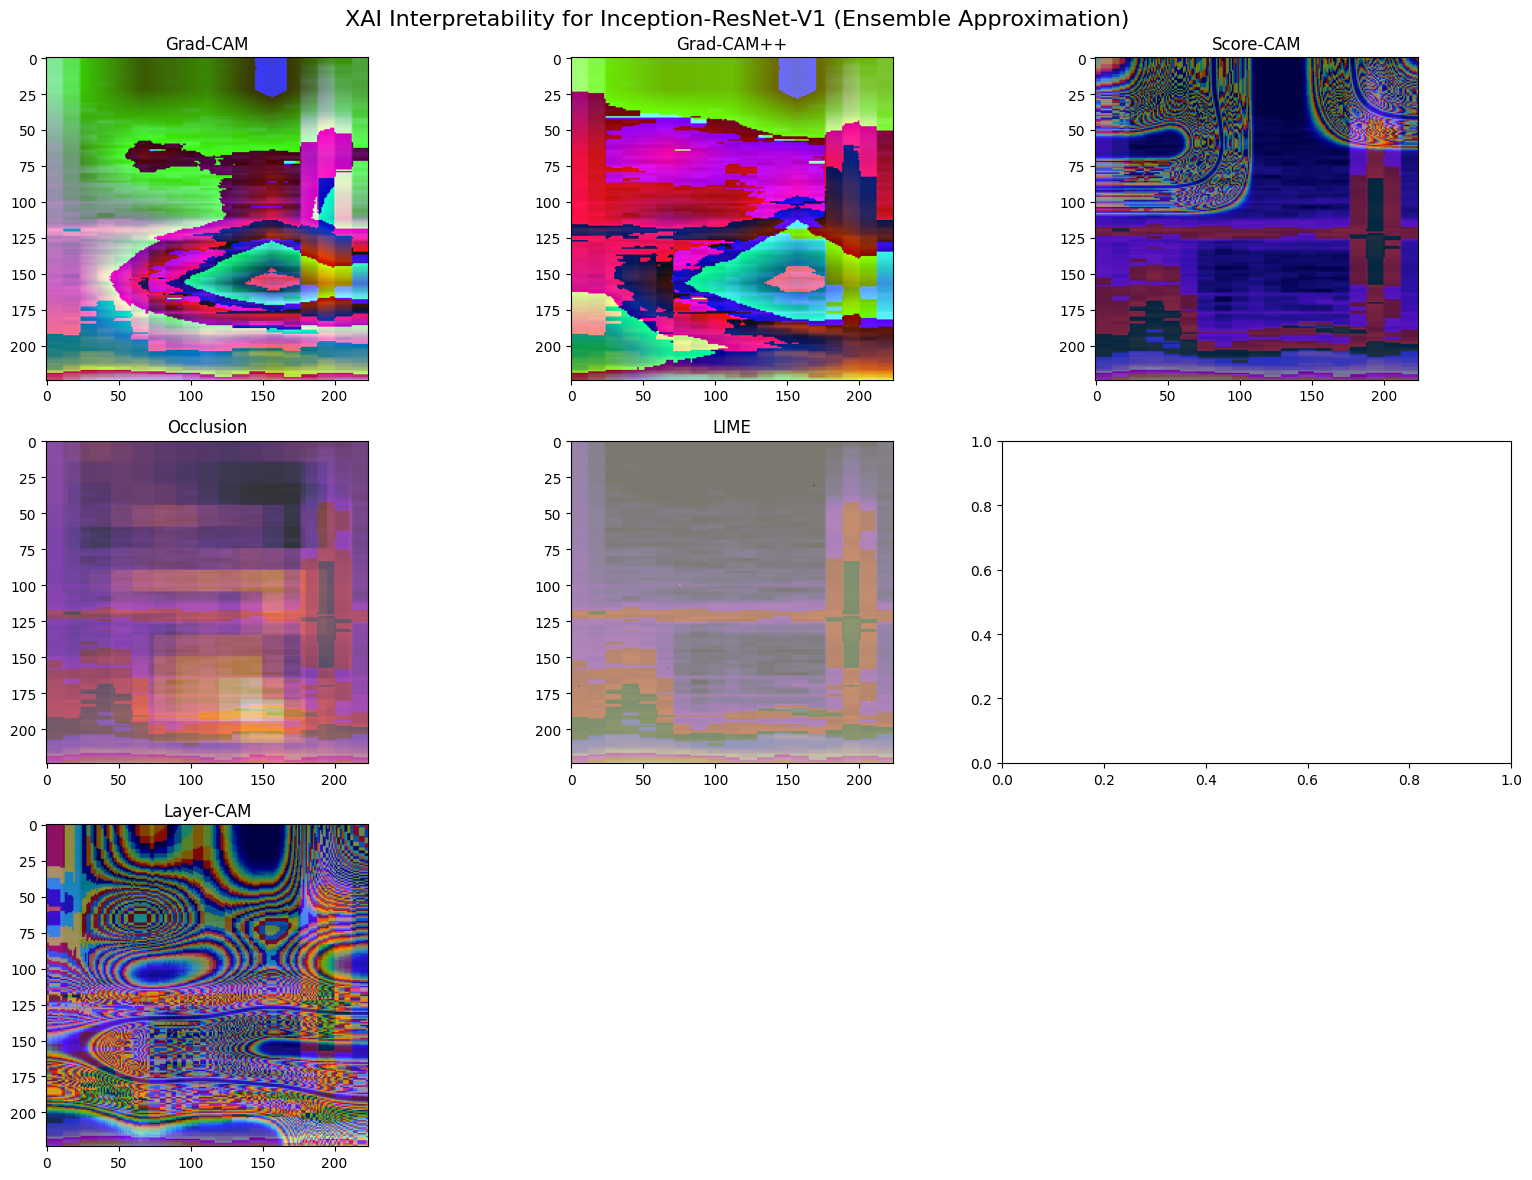

In [106]:
fig, axs = plt.subplots(3, 3, figsize=(16, 12))
axs = axs.ravel()

axs[0].imshow(show_cam_on_image(sample_img_np, grayscale_cam, use_rgb=True))
axs[0].set_title("Grad-CAM")

axs[1].imshow(show_cam_on_image(sample_img_np, grayscale_cam_pp, use_rgb=True))
axs[1].set_title("Grad-CAM++")

axs[2].imshow(score_overlay)
axs[2].set_title("Score-CAM")

axs[3].imshow(to_pil_image(sample_img.cpu()), alpha=0.6)
axs[3].imshow(attr_occ_map, cmap='inferno', alpha=0.5)
axs[3].set_title("Occlusion")

axs[4].imshow(to_pil_image(sample_img.cpu()), alpha=0.6)
axs[4].imshow(attr_lime_map, cmap='cividis', alpha=0.5)
axs[4].set_title("LIME")

# axs[5].imshow(to_pil_image(sample_img.cpu()), alpha=0.6)
# axs[5].imshow(attr_shap_map, cmap='viridis', alpha=0.5)
# axs[5].set_title("SHAP")

axs[6].imshow(layer_overlay)
axs[6].set_title("Layer-CAM")

# Hide unused plots
for ax in axs[7:]:
    ax.axis('off')

plt.suptitle("XAI Interpretability for Inception-ResNet-V1 (Ensemble Approximation)", fontsize=16)
plt.tight_layout()
plt.show()

In [107]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import Lime, ShapleyValueSampling, Occlusion
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from torchcam.methods import ScoreCAM, LayerCAM
from torchcam.utils import overlay_mask

In [142]:
# Sample one image from val_loader
sample_img, sample_label = val_loader.dataset[50]
input_tensor = sample_img.unsqueeze(0).to(device)
sample_img_np = sample_img.permute(1, 2, 0).cpu().numpy()
sample_img_np = sample_img_np / sample_img_np.max()

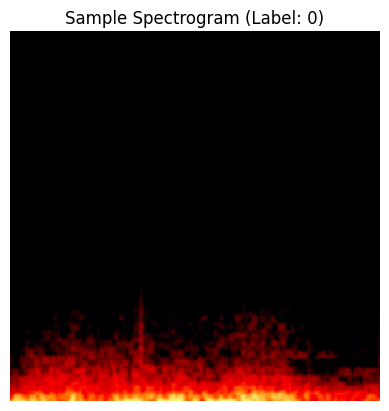

/kaggle/working/sample_spectrogram.png

In [143]:
import matplotlib.pyplot as plt

# Plot and save the spectrogram
plt.imshow(sample_img_np)
plt.title(f"Sample Spectrogram (Label: {sample_label})")
plt.axis('off')

# Save the figure
plt.savefig("sample_spectrogram.png", bbox_inches='tight', pad_inches=0.1)
plt.show()

# Optional: If using in Jupyter Notebook or Streamlit
# For Jupyter: provide a download link (display HTML)
from IPython.display import FileLink
display(FileLink("sample_spectrogram.png", result_html_prefix="Click here to download: "))


In [110]:
# Define your trained models
models = [resnet, xception, inception_v4, inception_resnet_v1, inception_resnet_v2, vgg19]

In [111]:
# Layer mappings for CAM methods
layer_lookup = {
    resnet: resnet.layer4[-1],
    xception: xception.conv2,
    inception_v4: inception_v4.features[-1],
    inception_resnet_v1: inception_resnet_v1.mixed_7a,
    inception_resnet_v2: inception_resnet_v2.mixed_7a,
    vgg19: vgg19.features[-1],
}

In [112]:
def average_cam(method_class, models, input_tensor, label, layer_lookup):
    maps = []
    for model in models:
        model.eval().to(device)
        cam = method_class(model=model, target_layers=[layer_lookup[model]])
        cam_map = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(label)])[0]
        maps.append(cam_map)
    return np.mean(maps, axis=0)

In [113]:
from torchcam.methods import ScoreCAM
import torch.nn.functional as F
import warnings

def average_scorecam(models, input_tensor, label, target_size=(224, 224), layer_lookup=None):
    maps = []
    input_tensor.requires_grad = True

    for model in models:
        model.eval().to(device)

        try:
            # Set model to training mode temporarily to allow hooks
            model.train()

            # Hook setup
            if layer_lookup is not None:
                cam = ScoreCAM(model, target_layer=layer_lookup.get(model), input_shape=(3, 224, 224))
            else:
                cam = ScoreCAM(model, input_shape=(3, 224, 224))

            # Use enable_grad explicitly (important)
            with torch.enable_grad():
                _ = model(input_tensor)

            cam_map = cam(label)[0]  # [H, W]

            if cam_map.dim() == 2:
                cam_map = cam_map.unsqueeze(0).unsqueeze(0)
            elif cam_map.dim() == 3:
                cam_map = cam_map.unsqueeze(0)

            cam_resized = F.interpolate(cam_map, size=target_size, mode='bilinear', align_corners=False)
            maps.append(cam_resized.squeeze().cpu().numpy())

        except Exception as e:
            warnings.warn(f"⚠️ ScoreCAM failed on {type(model).__name__}: {e}")

        finally:
            model.eval()  # Reset to eval mode

    if not maps:
        raise RuntimeError("❌ ScoreCAM failed on all models in the ensemble.")

    return np.mean(maps, axis=0)

In [114]:
import torch.nn.functional as F
import warnings

def average_layercam(models, input_tensor, label, target_size=(224, 224), layer_lookup=None):
    maps = []
    input_tensor.requires_grad = True  # Required for gradient-based CAMs

    for model in models:
        model.eval().to(device)
        try:
            # Use user-provided target layer or fallback to auto if not specified
            if layer_lookup is not None:
                cam = LayerCAM(model, target_layer=layer_lookup.get(model))
            else:
                cam = LayerCAM(model, input_shape=(3, 224, 224))

            with torch.enable_grad():  # Required for hook registration
                scores = model(input_tensor)

            # Compute CAM for target class
            cam_map = cam(class_idx=label, scores=scores)[0]  # shape: [H, W]

            # Ensure shape is [1, 1, H, W] for interpolation
            if cam_map.dim() == 2:
                cam_map = cam_map.unsqueeze(0).unsqueeze(0)
            elif cam_map.dim() == 3:
                cam_map = cam_map.unsqueeze(0)

            # Resize CAM to match input size (224x224)
            cam_resized = F.interpolate(cam_map, size=target_size, mode='bilinear', align_corners=False)
            maps.append(cam_resized.squeeze().cpu().numpy())

        except Exception as e:
            warnings.warn(f"⚠️ LayerCAM failed on {type(model).__name__}: {e}")

    if not maps:
        raise RuntimeError("❌ LayerCAM failed on all models in the ensemble.")

    return np.mean(maps, axis=0)


In [115]:
from captum.attr import Occlusion
import torch.nn.functional as F
import warnings
import numpy as n

def average_occlusion(models, input_tensor, label, target_size=(224, 224)):
    maps = []
    input_tensor.requires_grad = True

    for model in models:
        model.eval().to(device)
        try:
            occlusion = Occlusion(model)

            attr = occlusion.attribute(
                input_tensor,
                strides=(3, 15, 15),
                sliding_window_shapes=(3, 30, 30),
                baselines=0,
                target=label
            )  # shape: [1, 3, H, W]

            # Reduce over channels → [1, H, W]
            attr_mean = attr.mean(dim=1, keepdim=True)  # shape: [1, 1, H, W]

            # Resize to match target input size
            resized = F.interpolate(attr_mean, size=target_size, mode='bilinear', align_corners=False)
            maps.append(resized.squeeze().cpu().detach().numpy())

        except Exception as e:
            warnings.warn(f"⚠️ Occlusion failed on {type(model).__name__}: {e}")

    if not maps:
        raise RuntimeError("❌ Occlusion failed on all models in the ensemble.")

    return np.mean(maps, axis=0)

In [116]:
from captum.attr import Lime
import torch.nn.functional as F
import warnings

def average_lime(models, input_tensor, label, target_size=(224, 224)):
    maps = []
    input_tensor.requires_grad = True

    for model in models:
        model.eval().to(device)
        try:
            lime = Lime(model)

            attr = lime.attribute(input_tensor, target=label, n_samples=50)  # shape: [1, 3, H, W]
            attr_mean = attr.mean(dim=1, keepdim=True)  # → [1, 1, H, W]

            # Resize to 224x224 if needed
            resized = F.interpolate(attr_mean, size=target_size, mode='bilinear', align_corners=False)
            maps.append(resized.squeeze().cpu().detach().numpy())

        except Exception as e:
            warnings.warn(f"⚠️ LIME failed on {type(model).__name__}: {e}")

    if not maps:
        raise RuntimeError("❌ LIME failed on all models in the ensemble.")

    return np.mean(maps, axis=0)

In [117]:
# def average_shap(models, input_tensor, label):
#     maps = []
#     for model in models:
#         model.eval().to(device)
#         shap = ShapleyValueSampling(model)
#         shap_map = shap.attribute(input_tensor, target=label, n_samples=10)
#         maps.append(shap_map.squeeze().mean(dim=0).cpu().detach().numpy())
#     return np.mean(maps, axis=0)

In [118]:
# Run and store attribution maps
gradcam_map     = average_cam(GradCAM, models, input_tensor, sample_label, layer_lookup)
gradcampp_map   = average_cam(GradCAMPlusPlus, models, input_tensor, sample_label, layer_lookup)
#scorecam_map = average_scorecam(models, input_tensor, sample_label, layer_lookup=layer_lookup)
#layercam_map    = average_layercam(models, input_tensor, sample_label)
#occlusion_map   = average_occlusion(models, input_tensor, sample_label)
#lime_map        = average_lime(models, input_tensor, sample_label)
#shap_map        = average_shap(models, input_tensor, sample_label)

/kaggle/working/xai_outputs/grad-cam.png

/kaggle/working/xai_outputs/grad-cam++.png

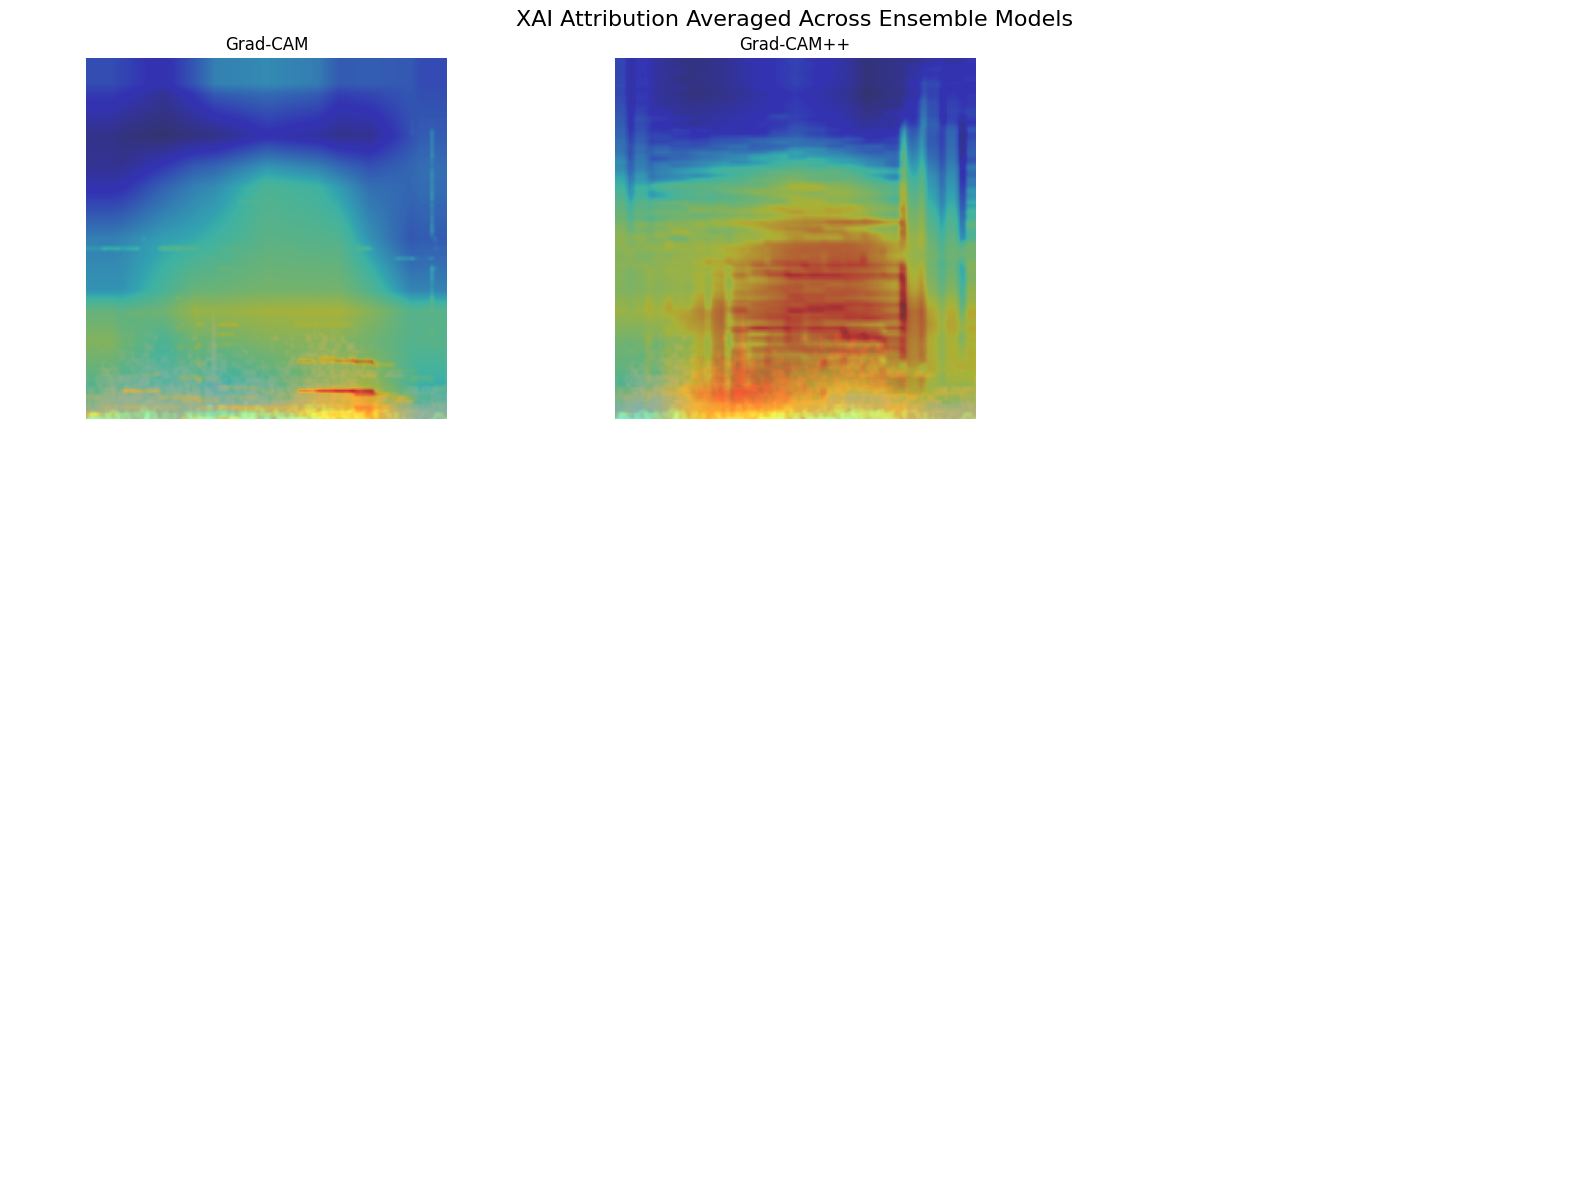

/kaggle/working/xai_outputs/combined_xai_maps.png

In [144]:
import matplotlib.pyplot as plt
import os

# Ensure output directory exists
output_dir = "xai_outputs"
os.makedirs(output_dir, exist_ok=True)

# Maps and Titles
maps = [gradcam_map, gradcampp_map]
titles = ["Grad-CAM", "Grad-CAM++"]

# Save each map individually
for i in range(len(maps)):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(sample_img_np, alpha=0.6)
    ax.imshow(maps[i], cmap='jet', alpha=0.5)
    ax.set_title(titles[i])
    ax.axis('off')

    filename = f"{titles[i].replace(' ', '_').lower()}.png"
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, bbox_inches='tight', pad_inches=0.1)
    plt.close()

    # For Jupyter: show download link
    from IPython.display import FileLink, display
    display(FileLink(filepath, result_html_prefix=f"Download {titles[i]} Map: "))

# Optional: Combined Grid Plot (like original)
fig, axs = plt.subplots(3, 3, figsize=(16, 12))
axs = axs.ravel()
for i in range(len(maps)):
    axs[i].imshow(sample_img_np, alpha=0.6)
    axs[i].imshow(maps[i], cmap='jet', alpha=0.5)
    axs[i].set_title(titles[i])
    axs[i].axis('off')
for i in range(len(maps), 9):
    axs[i].axis('off')

plt.suptitle("XAI Attribution Averaged Across Ensemble Models", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "combined_xai_maps.png"))
plt.show()

# Jupyter download link for combined image
display(FileLink(os.path.join(output_dir, "combined_xai_maps.png"), result_html_prefix="Download Combined XAI Map Grid: "))
